# **Data Practicum**

**Network Modelling of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 5: Co-Ocurence Modeling

Entity-Embeddings Model

In [1]:
# Loading the merged dataset and inspect its structure
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for year > 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()


Original shape: (470989, 33), after filtering year > 1999: (245779, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [2]:
# Checking Missing Values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


# Feature Engineering for Entity Embeddings - LSTM Model: Business Closure Prediction by Sector

Temporal features focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [3]:
# Defining closure targets and core metrics
import numpy as np

df = df.copy()

# Primary closure targets
df['closure_target'] = df['firmdeath_firms']  # Direct target for Entity Embeddings
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Normalized firm death rate

# Labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))


Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [4]:
# Engineering temporal lag features by sector
# Lagged features capture historical dependencies 

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))


Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [5]:
# Engineering derived features: moving averages and growth rates by sector
# These capture momentum and cyclical patterns in closure risk within sectors

# 3-year rolling averages smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Year-over-year growth rates capture macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())


Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [6]:
# Preparing sequences for LSTM (builds `sequences`, `targets`, `sequence_metadata`)
# Skipping sequences containing NaNs (e.g., from lag features)
import numpy as np

# Ensuring standard names exist
sequence_length = globals().get('sequence_length', 5)
group_cols = ['state_abbr', 'sector_name']

# Features
desired_features = [
    'closure_rate', 'ma3_closure_rate', 'lag1_closure_rate', 'lag2_closure_rate',
    'job_destruction_rate', 'ma3_job_destruction_rate', 'lag1_job_destruction_rate', 'lag2_job_destruction_rate',
    'net_job_creation_rate', 'reallocation_rate', 'income', 'population', 'employment_density', 'income_yoy'
]

feature_cols = [c for c in desired_features if c in df.columns]

sequences = []
targets = []
sequence_metadata = []

for (st, sec), grp in df.groupby(group_cols):
    grp = grp.sort_values('year')
    vals = grp[feature_cols].values
    tgts = grp['closure_target'].values
    years = grp['year'].dt.year.values
    for i in range(len(grp) - sequence_length + 1):
        seq = vals[i:i+sequence_length]
        tgt = tgts[i+sequence_length-1]
        tyear = years[i+sequence_length-1]
        # skip if any NaN in sequence or target
        if np.isnan(seq).any() or pd.isna(tgt):
            continue
        sequences.append(seq)
        targets.append(tgt)
        sequence_metadata.append({'state': st, 'sector': sec, 'start_year': int(years[i]), 'target_year': int(tyear)})

# Converting to arrays and dataframe
X = np.array(sequences)
y = np.array(targets)
metadata_df = pd.DataFrame(sequence_metadata)

print(f"Built sequences: {len(sequences)} (sequence_length={sequence_length}), feature_cols={len(feature_cols)}")


Built sequences: 240079 (sequence_length=5), feature_cols=14


In [7]:
# Ensuring variables exist when running this cell standalone
import pandas as pd
import numpy as np

# Building arrays from prepared lists
X = np.array(sequences)
y = np.array(targets)
metadata_df = pd.DataFrame(sequence_metadata)

# Correctly compute unique counts and group sizes
n_states = metadata_df['state'].nunique() if not metadata_df.empty else 0
n_sectors = metadata_df['sector'].nunique() if not metadata_df.empty else 0
n_groups = metadata_df.groupby(['state', 'sector']).ngroups if not metadata_df.empty else 0
mean_sequences_per_group = (len(sequences) / n_groups) if n_groups > 0 else 0

print(f"Sequence dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of unique states: {n_states}, unique sectors: {n_sectors}, total sector-state groups: {n_groups}")
print(f"Number of sequences per sector-state group (mean): {mean_sequences_per_group:.1f}")
print(f"\nFeatures used: {len(feature_cols)}")
print(f"Sequence length (temporal window): {sequence_length} years")

if y.size > 0:
    print("\nTarget variable distribution (closure_target):")
    print(f"  Mean: {y.mean():.2f}")
    print(f"  Std:  {y.std():.2f}")
    print(f"  Min:  {y.min():.2f}")
    print(f"  Max:  {y.max():.2f}")
else:
    print("\nNo target values available (y is empty)")


Sequence dataset shape: X=(240079, 5, 14), y=(240079,)
Number of unique states: 50, unique sectors: 19, total sector-state groups: 950
Number of sequences per sector-state group (mean): 252.7

Features used: 14
Sequence length (temporal window): 5 years

Target variable distribution (closure_target):
  Mean: 41.63
  Std:  89.68
  Min:  0.00
  Max:  2619.00


# State-Sector Business Closure Co-Occurrences

Aggregate closure target by state and sector:
  state_abbr                                        sector_name  \
0         AK                    Accommodation and Food Services   
1         AK  Administrative and Support and Waste Managemen...   
2         AK         Agriculture, Forestry, Fishing and Hunting   
3         AK                Arts, Entertainment, and Recreation   
4         AK                                       Construction   

   closure_target  
0         3064.00  
1         1601.50  
2          499.90  
3          704.25  
4         4122.50  

Top 10 state-sector combinations by average closure target:
    state_abbr                                       sector_name  \
89          CA  Professional, Scientific, and Technical Services   
91          CA                                      Retail Trade   
80          CA                                      Construction   
76          CA                   Accommodation and Food Services   
165         FL  Professional, 

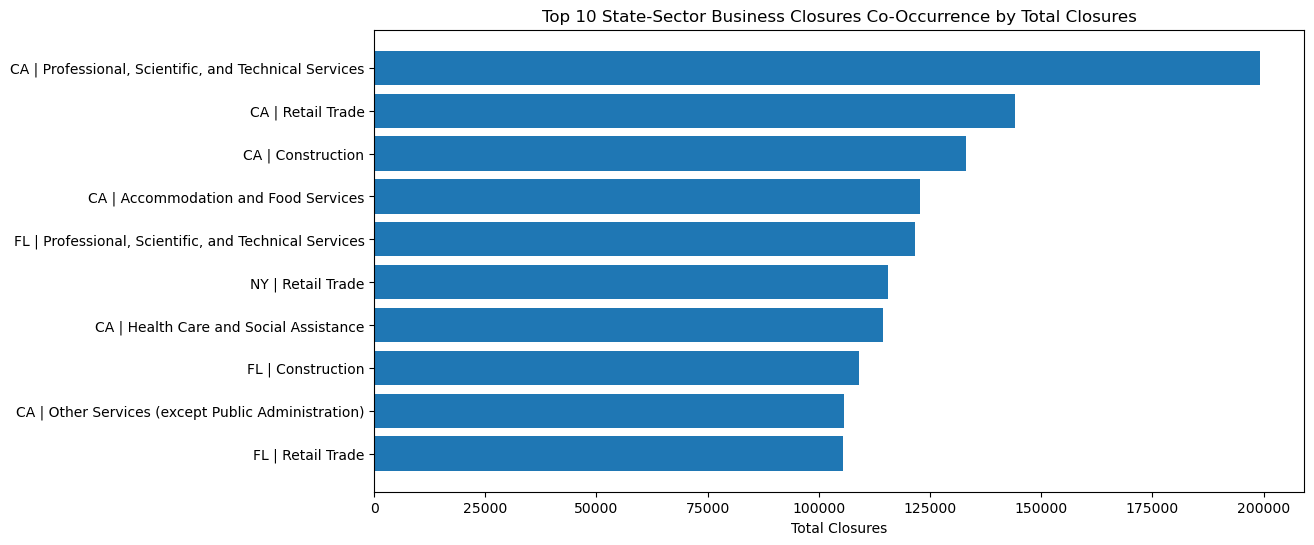

In [36]:
# Getting aggregate by state and sector for the closure target for full data
closure_agg = df.groupby(['state_abbr', 'sector_name'])['closure_target'].sum().reset_index()
print("Aggregate closure target by state and sector:")
print(closure_agg.head())

# Ploting top 10 most active combinations
top_n = 10
top_combinations = closure_agg.nlargest(top_n, 'closure_target')
print(f"\nTop {top_n} state-sector combinations by average closure target:")
print(top_combinations)

# Bar plot of top combinations
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 6))
plt.barh(top_combinations['state_abbr'] + ' | ' + top_combinations['sector_name'], top_combinations['closure_target'])
plt.xlabel('Total Closures')
plt.title(f'Top {top_n} State-Sector Business Closures Co-Occurrence by Total Closures')
plt.gca().invert_yaxis()
plt.show()



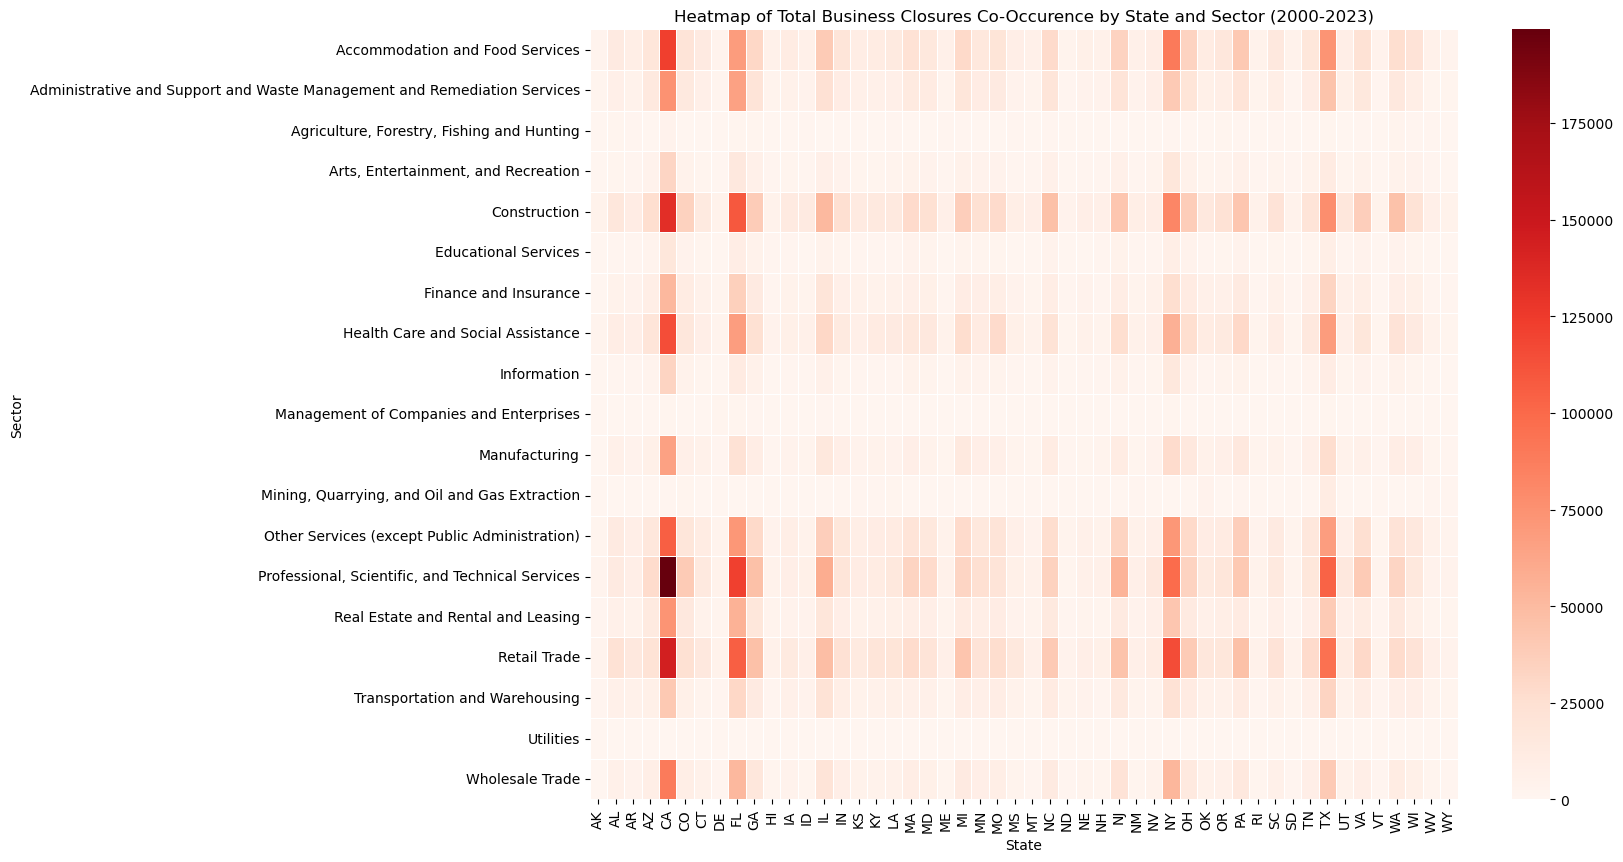

In [53]:
# Co-Occurrence Heatmap for full data aggregate, closure_agg
import seaborn as sns
plt.figure(figsize=(14, 10))
heatmap_data = closure_agg.pivot(index='sector_name', columns='state_abbr', values='closure_target').fillna(0)
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5)
plt.title('Heatmap of Total Business Closures Co-Occurence by State and Sector (2000-2023)')
plt.xlabel('State')
plt.ylabel('Sector') 
plt.show()

# Entity Embedding Modeling

State and sector are used as entities to model how business closures co-occur across both states and sectors in the entity embedding model. The data has 50 unique states, 19 unique sectors that result in 950 sector-state groups. 

In [8]:
# Encoding categorical variables for LSTM (state and sector embeddings) 
from sklearn.preprocessing import LabelEncoder


state_encoder = LabelEncoder()
sector_encoder = LabelEncoder()

metadata_df['state_abbr'] = state_encoder.fit_transform(
    metadata_df['state']
)

metadata_df['sector_name'] = sector_encoder.fit_transform(
    metadata_df['sector']
)

state_ids = metadata_df['state_abbr'].values
sector_ids = metadata_df['sector_name'].values

num_states = metadata_df['state_abbr'].nunique()
num_sectors = metadata_df['sector_name'].nunique()

print(num_states, num_sectors)


50 19


In [9]:
# Normalizing features for LSTM training (standardization)
from sklearn.preprocessing import StandardScaler

N, T, F = X.shape

scaler = StandardScaler()

X_2d = X.reshape(-1, F)

X_scaled = scaler.fit_transform(X_2d)

X_scaled = X_scaled.reshape(N, T, F)

## Data Preparation 

Partitioning of the data into training and testing set formed the initial data preparation approach for the modeling. Further, the data loaders were setup for the model to allow for the large dataset to be loaded efficiently to the model. 

In [10]:
# Splitting data into training and testing sets (80-20 split)
from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    state_train,
    state_test,
    sector_train,
    sector_test,
    y_train,
    y_test
) = train_test_split(
    X_scaled,
    state_ids,
    sector_ids,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Setting up data loaders 
import torch
from torch.utils.data import Dataset, DataLoader


class PanelDataset(Dataset):

    def __init__(
        self,
        X,
        state_ids,
        sector_ids,
        y
    ):

        self.X = torch.tensor(X, dtype=torch.float32)

        self.state_ids = torch.tensor(
            state_ids,
            dtype=torch.long
        )

        self.sector_ids = torch.tensor(
            sector_ids,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.state_ids[idx],
            self.sector_ids[idx],
            self.y[idx]
        )

train_dataset = PanelDataset(
    X_train,
    state_train,
    sector_train,
    y_train
)

test_dataset = PanelDataset(
    X_test,
    state_test,
    sector_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

## Model

The LSTM based Entity Embedding Model formed the model for the Entity Embedding Model by utilizing the state and sector entities within the LSTM framework. 


In [12]:
# LSTM Entity Embedding Model Definition
import torch.nn as nn

class LSTMEntityEmbeddingModel(nn.Module):

    def __init__(
        self,
        num_features,
        num_states,
        num_sectors,
        lstm_hidden=64,
        state_emb_dim=8,
        sector_emb_dim=16
    ):

        super().__init__()

        
        # Embeddings

        self.state_embedding = nn.Embedding(
            num_states,
            state_emb_dim
        )

        self.sector_embedding = nn.Embedding(
            num_sectors,
            sector_emb_dim
        )

        
        # LSTM

        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        
        # Network architecture: LSTM + Entity Embeddings + Fully Connected Layers
       

        combined_dim = (
            lstm_hidden
            + state_emb_dim
            + sector_emb_dim
        )

        self.fc = nn.Sequential(

            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(
        self,
        x_seq,
        state_ids,
        sector_ids
    ):

        
        # LSTM

        _, (hidden, _) = self.lstm(x_seq)

        seq_repr = hidden[-1]

        # Embeddings

        state_emb = self.state_embedding(state_ids)

        sector_emb = self.sector_embedding(sector_ids)

        
        # Concatenate

        combined = torch.cat(
            [
                seq_repr,
                state_emb,
                sector_emb
            ],
            dim=1
        )

        out = self.fc(combined)

        return out.squeeze()


In [13]:
# Model Setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTMEntityEmbeddingModel(
    num_features=F,
    num_states=num_states,
    num_sectors=num_sectors
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [42]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [43]:
from tabulate import tabulate
import pandas as pd

rows = []

for name, module in model.named_modules():

    if name == "":
        continue

    params = sum(
        p.numel()
        for p in module.parameters(recurse=False)
    )

    rows.append([
        name,
        module.__class__.__name__,
        f"{params:,}"
    ])

summary_df = pd.DataFrame(
    rows,
    columns=[
        "Layer Name",
        "Layer Type",
        "Param #"
    ]
)

print(
    tabulate(
        summary_df,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n" + "="*70)
print(f"Total params:      {total_params:,}")
print(f"Trainable params:  {trainable_params:,}")
print(f"Non-trainable:     {total_params - trainable_params:,}")
print("="*70)

+------------------+--------------+-----------+
| Layer Name       | Layer Type   |   Param # |
+==================+==============+===========+
| state_embedding  | Embedding    |       400 |
+------------------+--------------+-----------+
| sector_embedding | Embedding    |       304 |
+------------------+--------------+-----------+
| lstm             | LSTM         |    53,760 |
+------------------+--------------+-----------+
| fc               | Sequential   |         0 |
+------------------+--------------+-----------+
| fc.0             | Linear       |    11,392 |
+------------------+--------------+-----------+
| fc.1             | ReLU         |         0 |
+------------------+--------------+-----------+
| fc.2             | Dropout      |         0 |
+------------------+--------------+-----------+
| fc.3             | Linear       |     8,256 |
+------------------+--------------+-----------+
| fc.4             | ReLU         |         0 |
+------------------+--------------+-----

In [14]:
# Training Loop

def train_epoch():

    model.train()

    total_loss = 0

    for (
        seq_batch,
        state_batch,
        sector_batch,
        y_batch
    ) in train_loader:

        seq_batch = seq_batch.to(device)

        state_batch = state_batch.to(device)

        sector_batch = sector_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(
            seq_batch,
            state_batch,
            sector_batch
        )

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    preds_all = []
    targets_all = []

    with torch.no_grad():

        for (
            seq_batch,
            state_batch,
            sector_batch,
            y_batch
        ) in loader:

            seq_batch = seq_batch.to(device)

            state_batch = state_batch.to(device)

            sector_batch = sector_batch.to(device)

            preds = model(
                seq_batch,
                state_batch,
                sector_batch
            )

            preds_all.extend(
                preds.cpu().numpy()
            )

            targets_all.extend(
                y_batch.numpy()
            )

    preds_all = np.array(preds_all)

    targets_all = np.array(targets_all)

    # Metrics

    rmse = np.sqrt(
        mean_squared_error(
            targets_all,
            preds_all
        )
    )

    mae = mean_absolute_error(
        targets_all,
        preds_all
    )

    r2 = r2_score(
        targets_all,
        preds_all
    )

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

    return metrics, preds_all, targets_all



In [18]:
# Training Model

epochs = 20

history = []

for epoch in range(epochs):

    # Training

    model.train()

    total_loss = 0

    for (
        seq_batch,
        state_batch,
        sector_batch,
        y_batch
    ) in train_loader:

        seq_batch = seq_batch.to(device)

        state_batch = state_batch.to(device)

        sector_batch = sector_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(
            seq_batch,
            state_batch,
            sector_batch
        )

        loss = criterion(
            preds,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # Evaluating Train

    train_metrics, _, _ = evaluate_model(
        model,
        train_loader,
        device
    )

    # Evaluating Test

    test_metrics, test_preds, test_actuals = evaluate_model(
        model,
        test_loader,
        device
    )

    # Storing History

    history.append({
        'epoch': epoch + 1,

        'train_loss': train_loss,

        'train_rmse': train_metrics['RMSE'],
        'train_mae': train_metrics['MAE'],
        'train_r2': train_metrics['R2'],

        'test_rmse': test_metrics['RMSE'],
        'test_mae': test_metrics['MAE'],
        'test_r2': test_metrics['R2']
    })

    # Metrics

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Train R2: {train_metrics['R2']:.4f} | "
        f"Test R2: {test_metrics['R2']:.4f} | "
        f"Train MAE: {train_metrics['MAE']:.4f} | "
        f"Test MAE: {test_metrics['MAE']:.4f}"
    )


Epoch 01 | Loss: 335.6969 | Train R2: 0.9776 | Test R2: 0.9720 | Train MAE: 6.4407 | Test MAE: 6.6397
Epoch 02 | Loss: 332.3573 | Train R2: 0.9710 | Test R2: 0.9659 | Train MAE: 6.7389 | Test MAE: 6.8321
Epoch 03 | Loss: 327.4602 | Train R2: 0.9790 | Test R2: 0.9744 | Train MAE: 6.2527 | Test MAE: 6.4267
Epoch 04 | Loss: 314.9608 | Train R2: 0.9743 | Test R2: 0.9692 | Train MAE: 7.0102 | Test MAE: 7.1798
Epoch 05 | Loss: 319.6103 | Train R2: 0.9731 | Test R2: 0.9687 | Train MAE: 6.4247 | Test MAE: 6.5760
Epoch 06 | Loss: 322.0471 | Train R2: 0.9755 | Test R2: 0.9699 | Train MAE: 6.7210 | Test MAE: 6.8925
Epoch 07 | Loss: 305.6653 | Train R2: 0.9792 | Test R2: 0.9731 | Train MAE: 6.2064 | Test MAE: 6.4001
Epoch 08 | Loss: 303.4087 | Train R2: 0.9801 | Test R2: 0.9757 | Train MAE: 6.1379 | Test MAE: 6.3217
Epoch 09 | Loss: 307.2891 | Train R2: 0.9789 | Test R2: 0.9741 | Train MAE: 6.7946 | Test MAE: 6.9871
Epoch 10 | Loss: 294.3198 | Train R2: 0.9820 | Test R2: 0.9777 | Train MAE: 5.9637

In [44]:
# Storing history in DataFrame

history_df = pd.DataFrame(history)

print(history_df.tail())


    epoch  train_loss  train_rmse  train_mae  train_r2  test_rmse  test_mae  \
15     16  270.378346   11.905867   6.087023  0.982515  13.335248  6.293407   
16     17  280.979497   11.795929   5.949353  0.982837  13.022351  6.154867   
17     18  271.717085   11.467851   6.025594  0.983778  13.101394  6.288188   
18     19  279.637197   11.359883   5.803335  0.984082  13.026176  6.030094   
19     20  275.881390   11.557643   5.993906  0.983523  12.951882  6.202183   

     test_r2  
15  0.977153  
16  0.978213  
17  0.977948  
18  0.978200  
19  0.978448  


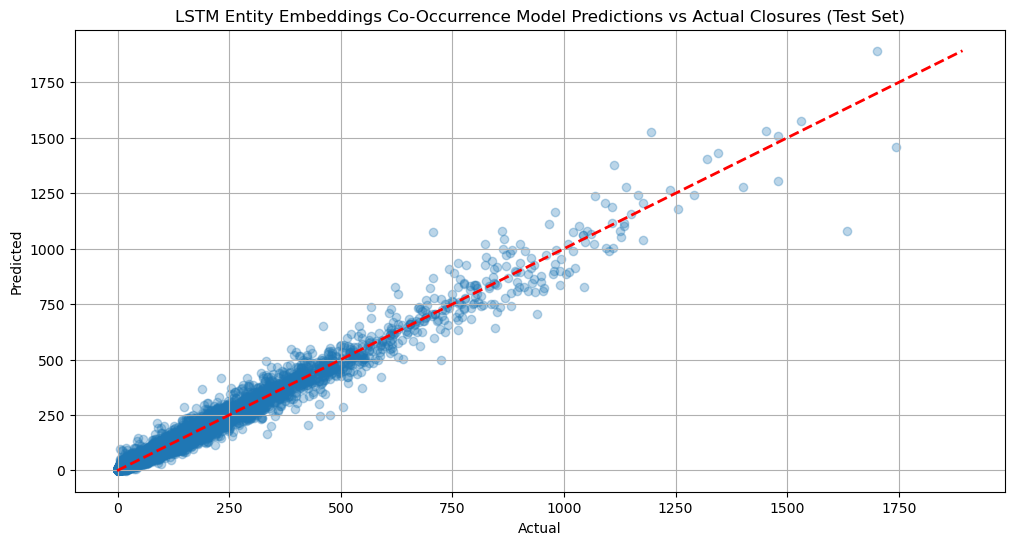

In [46]:
# Actual vs Predicted Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    test_actuals,
    test_preds,
    alpha=0.3
)

# Perfect prediction line
min_val = min(
    test_actuals.min(),
    test_preds.min()
)

max_val = max(
    test_actuals.max(),
    test_preds.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("LSTM Entity Embeddings Co-Occurrence Model Predictions vs Actual Closures (Test Set)")

plt.grid(True)

plt.show()


# Co-occurrence Plots

In [21]:
# State-Sector Actual vs Predicted

# Test Metadata

indices = np.arange(len(X_scaled))

(
    train_idx,
    test_idx
) = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

test_metadata = metadata_df.iloc[
    test_idx
].copy()

test_metadata['actual'] = test_actuals
test_metadata['predicted'] = test_preds
test_metadata.head()


,state,sector,start_year,target_year,state_abbr,sector_name,actual,predicted
230236,WI,Utilities,2013,2013,47,17,0.0,2.015039
139470,NH,Accommodation and Food Services,2016,2017,29,0,14.0,15.275341
100803,MI,Accommodation and Food Services,2000,2000,21,0,28.0,30.424742
157394,NV,Real Estate and Rental and Leasing,2015,2015,32,14,2.5,7.171571
56341,IA,Real Estate and Rental and Leasing,2017,2017,11,14,7.0,12.989079


In [22]:
# Aggregating test metadata by state and sector 
cooccurrence_df = (
    test_metadata
    .groupby(
        ['state', 'sector']
    )
    .agg({
        'actual': 'mean',
        'predicted': 'mean'
    })
    .reset_index()
)

print(cooccurrence_df.head())



  state                                             sector     actual  \
0    AK                    Accommodation and Food Services  10.627451   
1    AK  Administrative and Support and Waste Managemen...   6.727273   
2    AK         Agriculture, Forestry, Fishing and Hunting   1.665504   
3    AK                Arts, Entertainment, and Recreation   2.885476   
4    AK                                       Construction  16.039215   

   predicted  
0  11.258169  
1   8.223965  
2   2.096538  
3   4.009522  
4  18.034018  


In [32]:
# State-Sector Label

cooccurrence_df['state_sector'] = (
    cooccurrence_df['state']
    + " | "
    + cooccurrence_df['sector']
)

# Top 10 most active combinations

top_n = 10

top_combinations = (
    test_metadata
    .groupby(['state', 'sector'])
    .size()
    .reset_index(name='count')
    .sort_values(
        'count',
        ascending=False
    )
    .head(top_n)
)



In [33]:
# Plot Data

plot_df = pd.merge(
    cooccurrence_df,
    top_combinations[['state', 'sector']],
    on=['state', 'sector']
)

# Sorted Ploting

plot_df = plot_df.sort_values(
    'actual',
    ascending=False
)



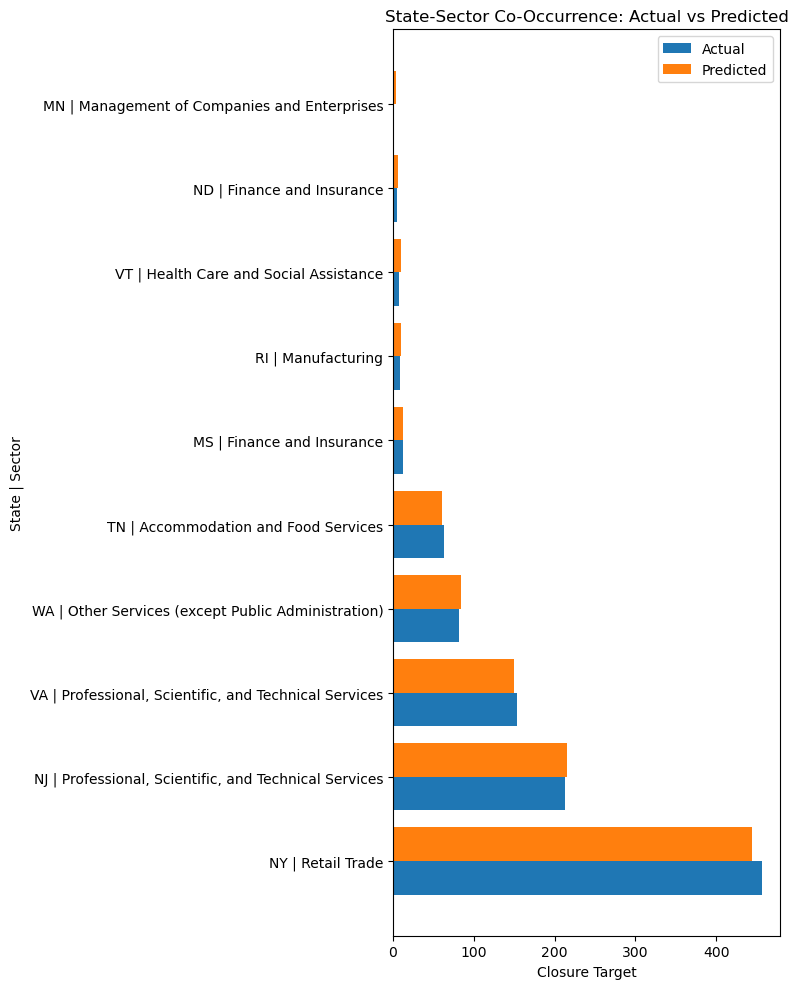

In [51]:
# Actual vs Predicted Bar Plot for State-Sector Combinations

x = np.arange(len(plot_df))

width = 0.4

plt.figure(figsize=(8, 10))

plt.barh(
    x - width/2,
    plot_df['actual'],
    height=width,
    label='Actual'
)

plt.barh(
    x + width/2,
    plot_df['predicted'],
    height=width,
    label='Predicted'
)

plt.yticks(
    x,
    plot_df['state_sector']
)

plt.xlabel("Closure Target")

plt.ylabel("State | Sector")

plt.title(
    "State-Sector Co-Occurrence: Actual vs Predicted"
)

plt.legend()

plt.tight_layout()

plt.show()



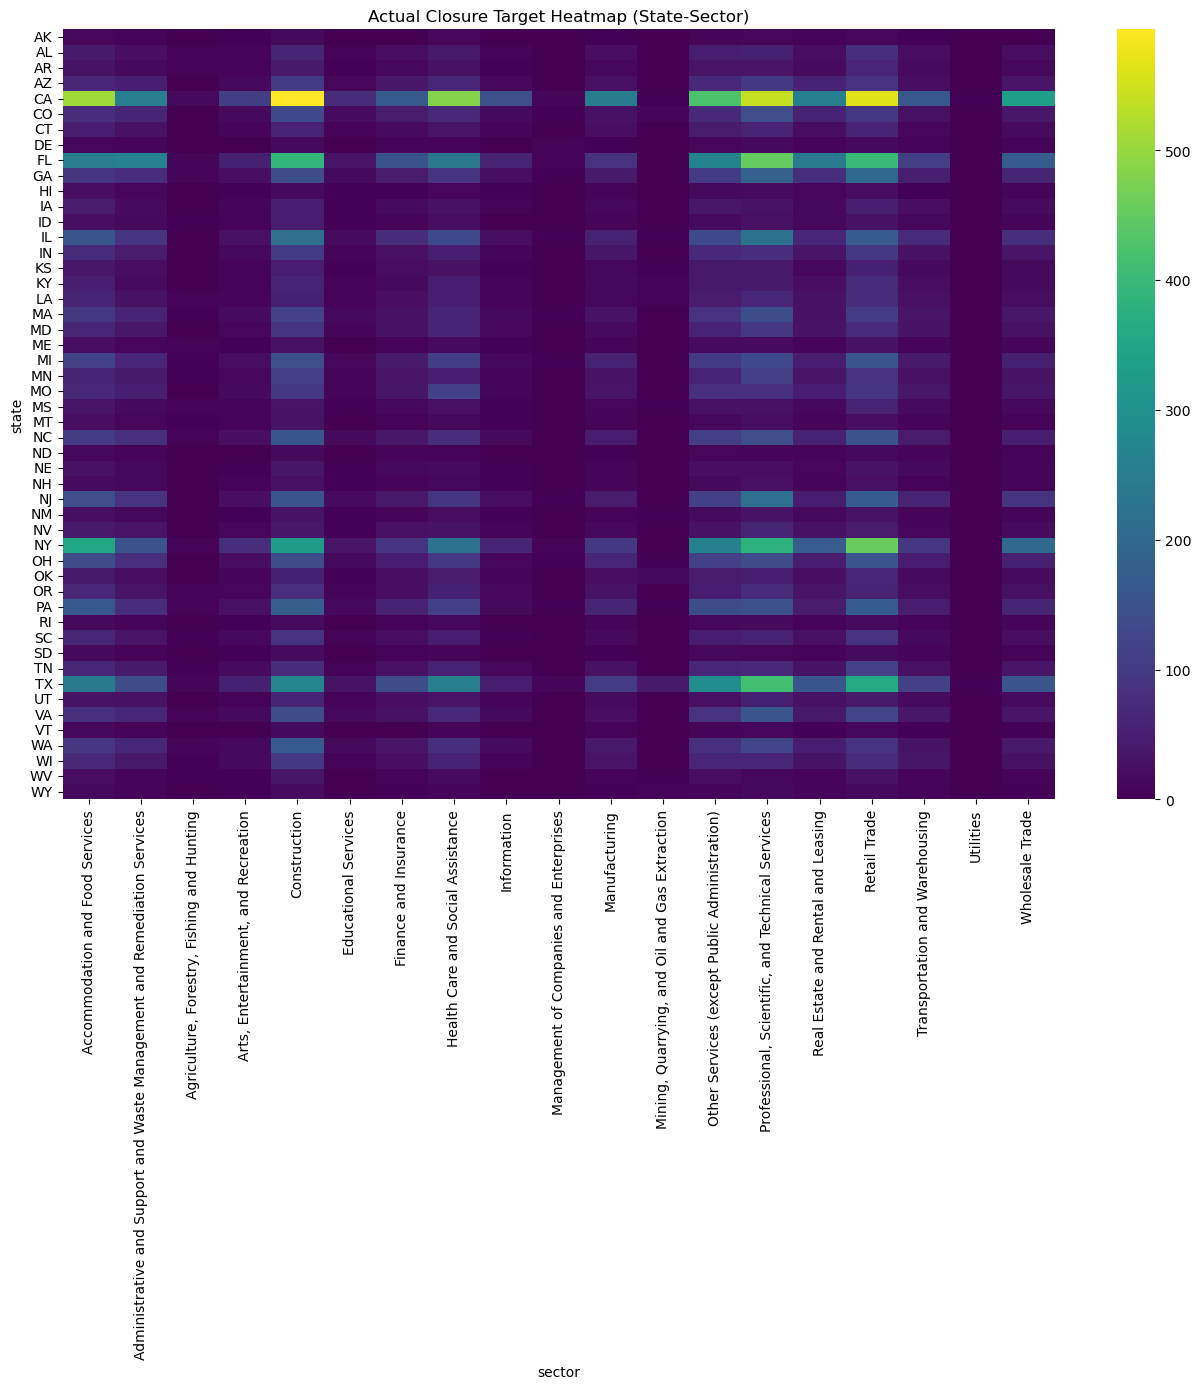

In [35]:
# Actual Values Heatmap
import seaborn as sns

heat_actual = (
    cooccurrence_df
    .pivot_table(
        index='state',
        columns='sector',
        values='actual'
    )
)

plt.figure(figsize=(16, 10))

sns.heatmap(
    heat_actual,
    cmap='viridis'
)

plt.title(
    "Actual Closure Target Heatmap (State-Sector)"
)

plt.show()



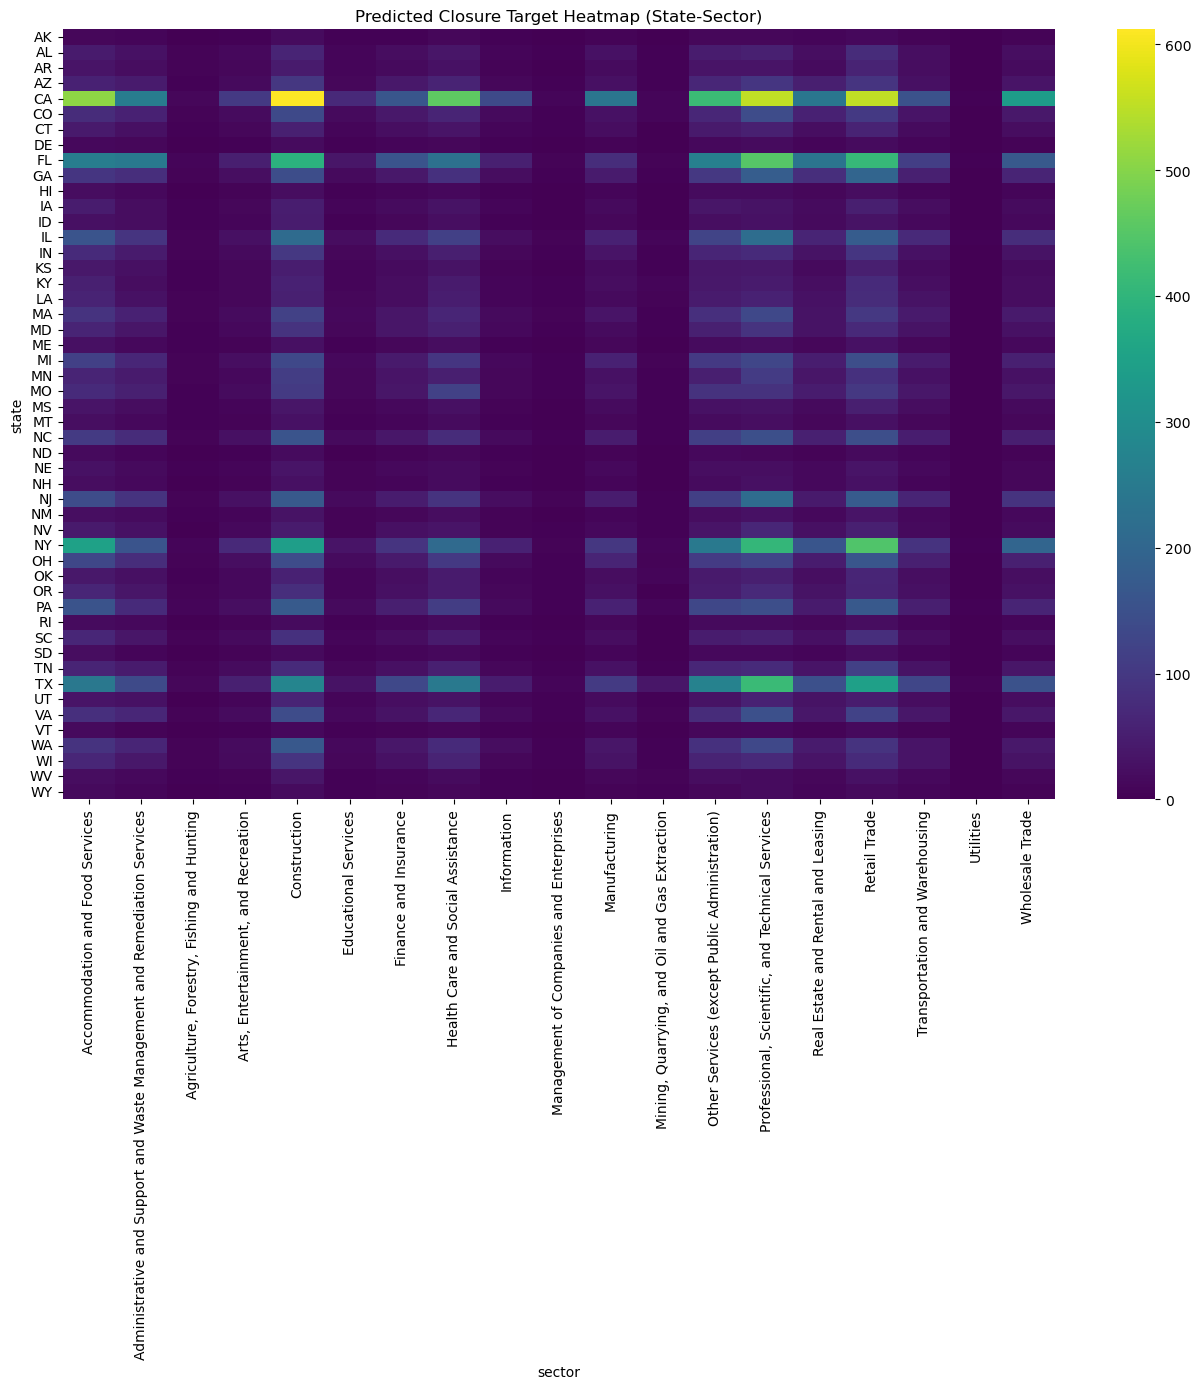

In [27]:
# Predicted Values Heatmap

heat_pred = (
    cooccurrence_df
    .pivot_table(
        index='state',
        columns='sector',
        values='predicted'
    )
)

plt.figure(figsize=(16, 10))

sns.heatmap(
    heat_pred,
    cmap='viridis'
)

plt.title(
    "Predicted Closure Target Heatmap (State-Sector)"
)

plt.show()



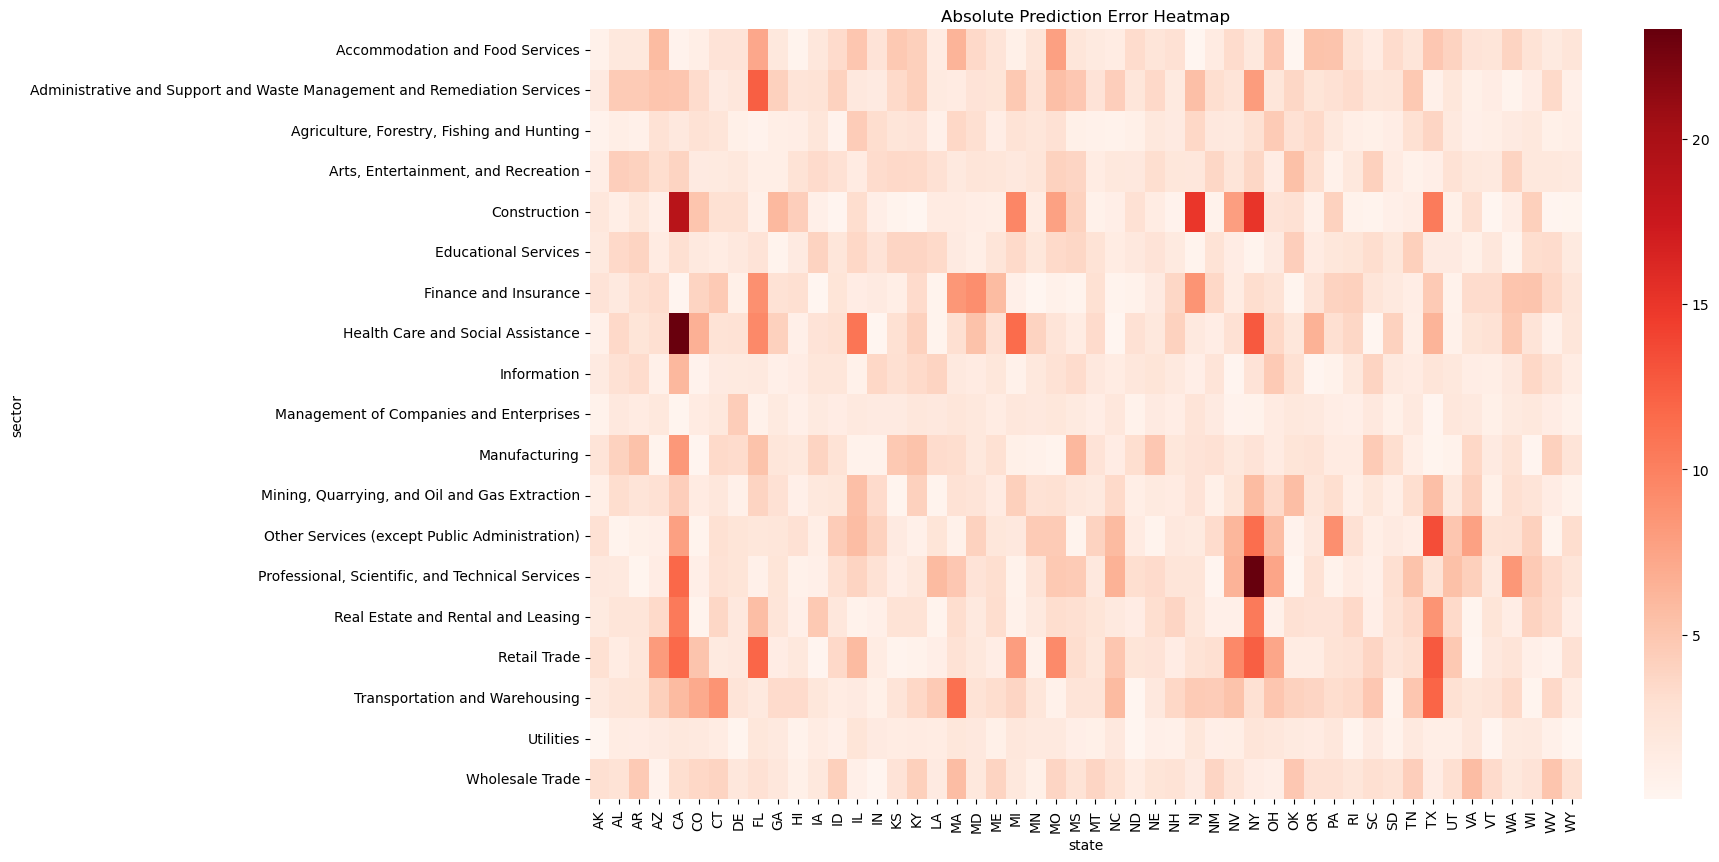

In [52]:
# Error Heatmap

cooccurrence_df['abs_error'] = np.abs(
    cooccurrence_df['actual']
    - cooccurrence_df['predicted']
)

heat_error = (
    cooccurrence_df
    .pivot_table(
        index='sector',
        columns='state',
        values='abs_error'
    )
)

plt.figure(figsize=(16, 10))

sns.heatmap(
    heat_error,
    cmap='Reds'
)

plt.title(
    "Absolute Prediction Error Heatmap"
)

plt.show()